<center><h1>Hou_Tianbo_HW2</h1></center>
<br>

Name: Hou Tianbo
<br>
Github Username: **TODO_FILL_GITHUB_USERNAME**
<br>
USC ID: **TODO_FILL_USC_ID**

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 20)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

Get the Cycle Power Plant Data Set

In [2]:
import os
# Locate the data file with a RELATIVE path (works regardless of OS/cwd).
data_path = None
for parent in ['.'] + ['..'] * 5:
    cand = os.path.join(parent, 'data', 'CCPP', 'Folds5x2_pp.xlsx')
    if os.path.exists(cand):
        data_path = cand
        break
assert data_path is not None, 'Could not locate data/CCPP/Folds5x2_pp.xlsx'
print('Loading data from:', data_path)
df = pd.read_excel(data_path)
print(df.shape)
df.head()

Loading data from: .\data\CCPP\Folds5x2_pp.xlsx
(9568, 5)


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [3]:
n_rows, n_cols = df.shape
print(f'Number of rows: {n_rows}')
print(f'Number of columns: {n_cols}')
print('Columns:', list(df.columns))
print()
print('Each row is one hourly-averaged recording from the power plant.')
print('Columns AT (Temperature), V (Exhaust Vacuum), AP (Ambient Pressure), RH (Relative Humidity) are predictors; PE (net hourly electrical energy output) is the response.')
df.describe()

Number of rows: 9568
Number of columns: 5
Columns: ['AT', 'V', 'AP', 'RH', 'PE']

Each row is one hourly-averaged recording from the power plant.
Columns AT (Temperature), V (Exhaust Vacuum), AP (Ambient Pressure), RH (Relative Humidity) are predictors; PE (net hourly electrical energy output) is the response.


,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


#### ii. pairwise scatterplots of all the variables

D:\download\Anaconda\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\download\Anaconda\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\download\Anaconda\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
D:\download\Anaconda\anaconda\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to 

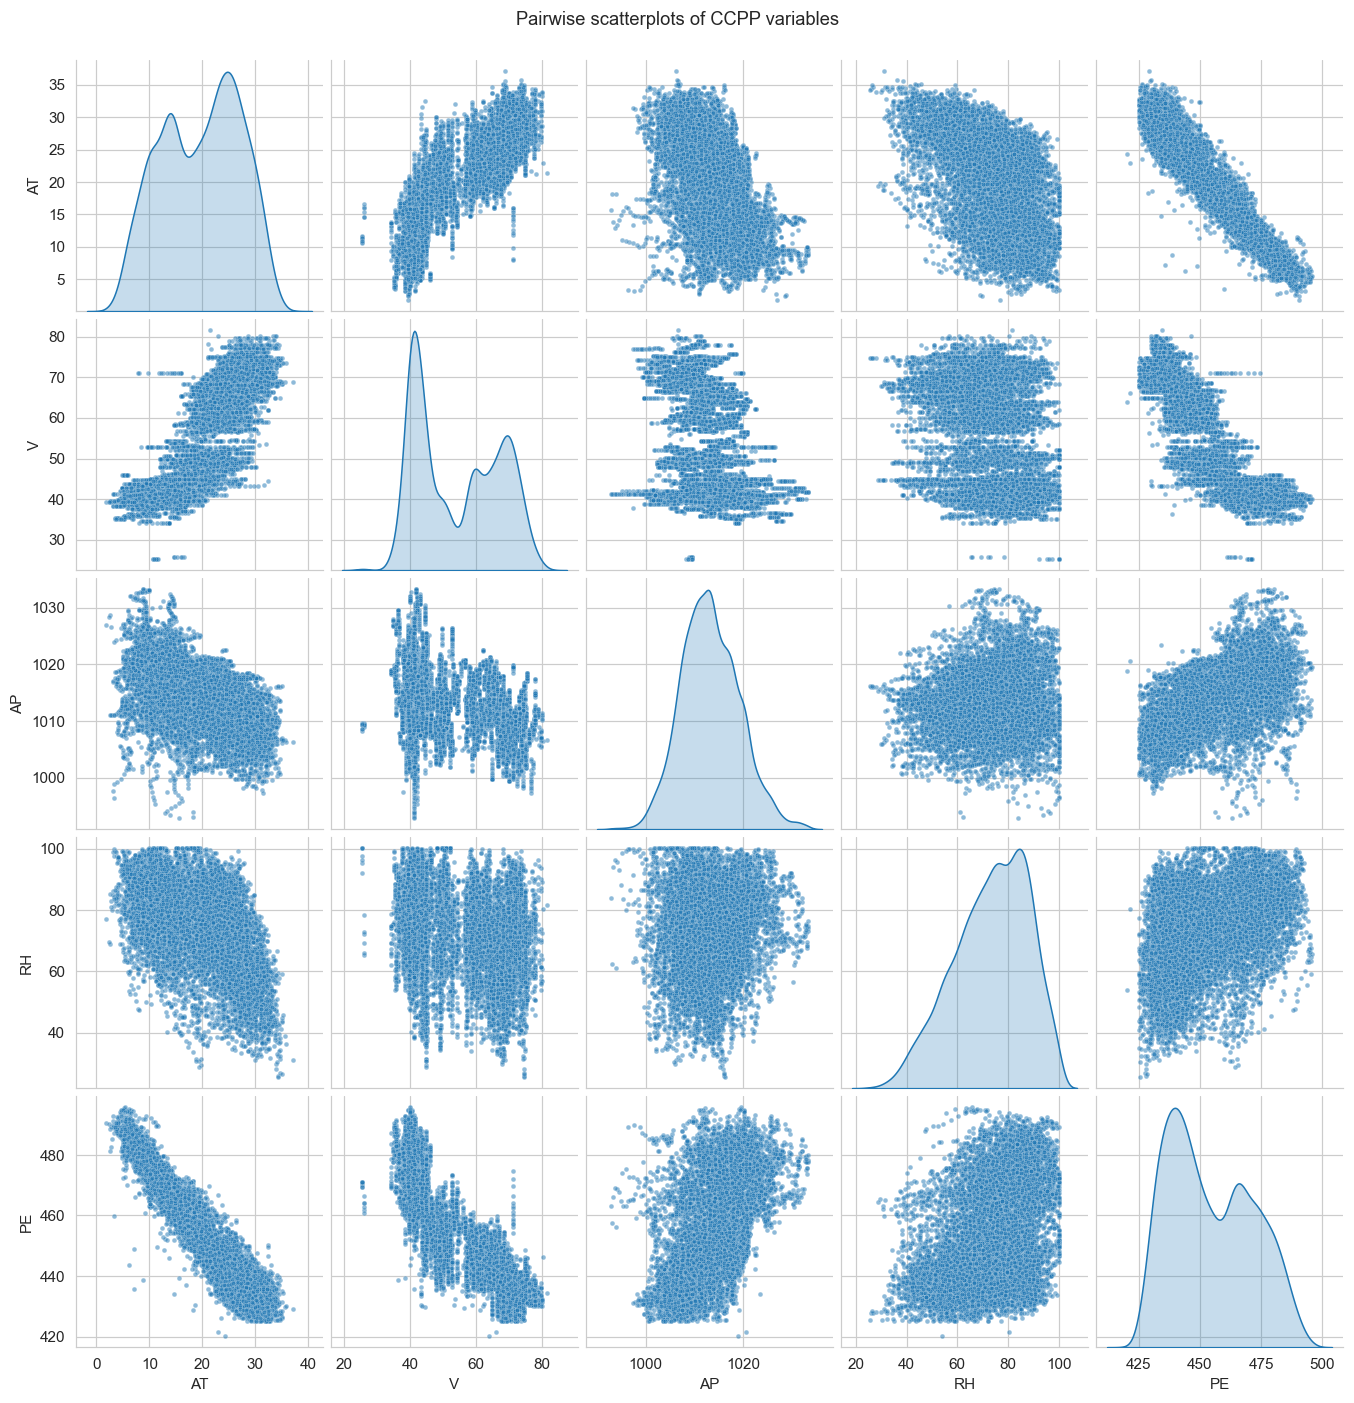

In [4]:
sns.pairplot(df, diag_kind='kde', plot_kws={'s': 10, 'alpha': 0.5})
plt.suptitle('Pairwise scatterplots of CCPP variables', y=1.02)
plt.show()

**Findings:**
- `AT` (Temperature) shows a strong negative, near-linear relationship with `PE` (output).
- `V` (Exhaust Vacuum) also shows a clear negative association with `PE`.
- `AP` and `RH` show weaker/weaker linear associations with `PE`.
- Among predictors, `AT` and `V` are positively correlated; the others are fairly independent.

#### iii. mean, median, range, quartiles, IQR

In [5]:
stats = pd.DataFrame({
    'mean': df.mean(),
    'median': df.median(),
    'min': df.min(),
    'max': df.max(),
    'range': df.max() - df.min(),
    'Q1': df.quantile(0.25),
    'Q3': df.quantile(0.75),
    'IQR': df.quantile(0.75) - df.quantile(0.25),
})
stats.round(3)

,mean,median,min,max,range,Q1,Q3,IQR
AT,19.651,20.345,1.81,37.11,35.30,13.510,25.72,12.210
V,54.306,52.080,25.36,81.56,56.20,41.740,66.54,24.800
AP,1013.259,1012.940,992.89,1033.30,40.41,1009.100,1017.26,8.160
RH,73.309,74.975,25.56,100.16,74.60,63.328,84.83,21.502
PE,454.365,451.550,420.26,495.76,75.50,439.750,468.43,28.680


### (c) Simple Linear Regression

In [6]:
X = df[['AT', 'V', 'AP', 'RH']]
y = df['PE']

uni_coefs = {}
for pred in X.columns:
    Xs = sm.add_constant(X[[pred]])
    model = sm.OLS(y, Xs).fit()
    uni_coefs[pred] = model.params[pred]
    print(f'--- PE ~ {pred} ---')
    print(f'coef = {model.params[pred]:.4f}, p-value = {model.pvalues[pred]:.3e}, R^2 = {model.rsquared:.4f}')
    print()

--- PE ~ AT ---
coef = -2.1713, p-value = 0.000e+00, R^2 = 0.8989

--- PE ~ V ---
coef = -1.1681, p-value = 0.000e+00, R^2 = 0.7565

--- PE ~ AP ---
coef = 1.4899, p-value = 0.000e+00, R^2 = 0.2688

--- PE ~ RH ---
coef = 0.4557, p-value = 0.000e+00, R^2 = 0.1519



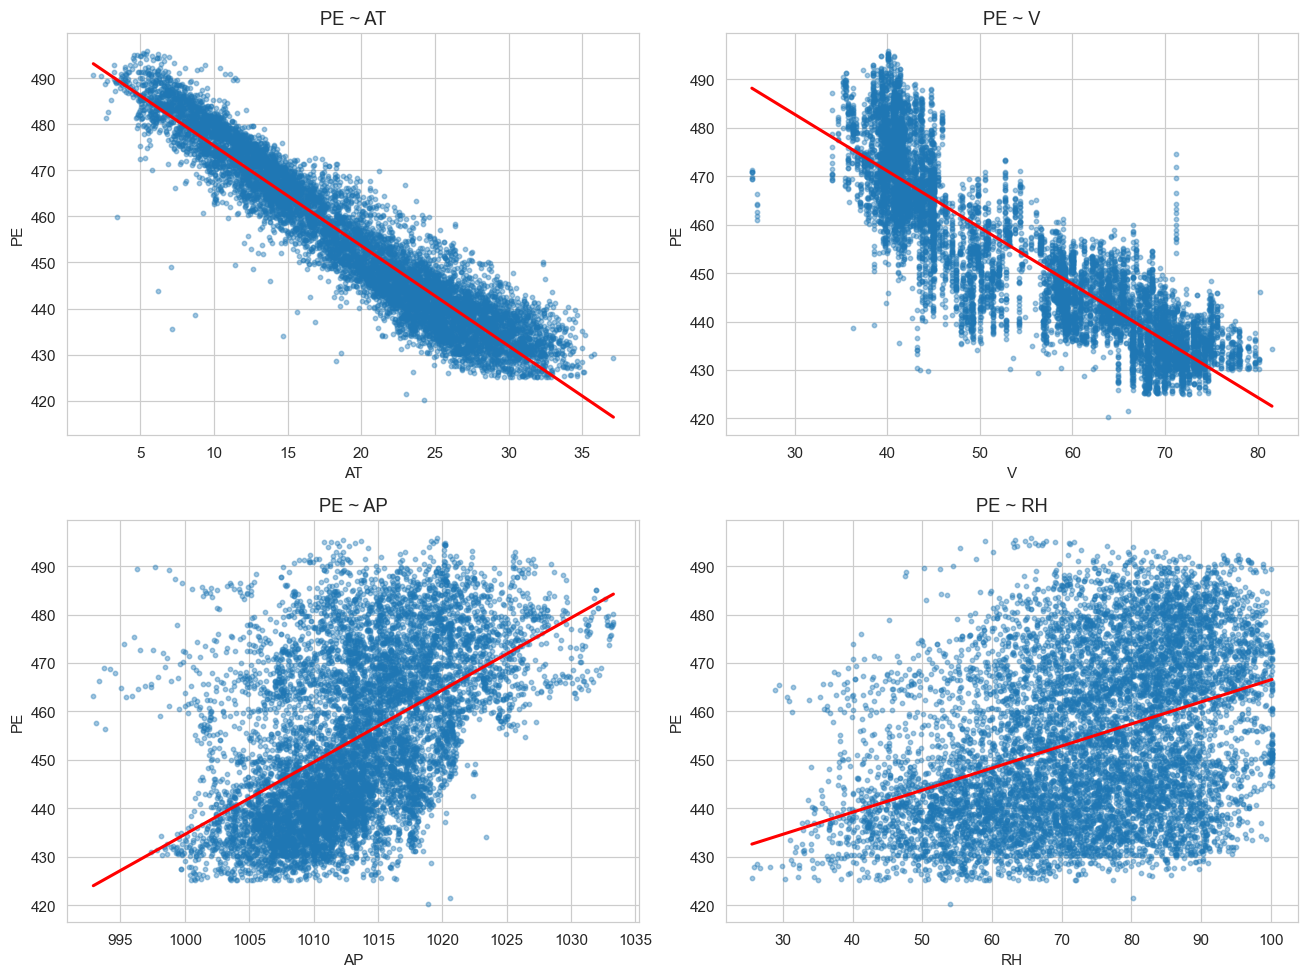

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, pred in zip(axes.ravel(), X.columns):
    ax.scatter(X[pred], y, s=8, alpha=0.4)
    b1 = uni_coefs[pred]
    b0 = y.mean() - b1 * X[pred].mean()
    xs = np.linspace(X[pred].min(), X[pred].max(), 100)
    ax.plot(xs, b0 + b1 * xs, color='red', lw=2)
    ax.set_xlabel(pred)
    ax.set_ylabel('PE')
    ax.set_title(f'PE ~ {pred}')
plt.tight_layout()
plt.show()

**Results:** Every predictor has a statistically significant (p < 0.001) association with the response in a simple linear model. `AT` and `V` are by far the strongest (high R^2), `AP` and `RH` are weaker but still significant.
Outliers: the cloud of points is fairly tight; there are no extreme outliers that would justify removal, though a few high-leverage points at the edges of `V`/`AT` could be noted. We keep all data.

### (d) Multiple Regression

In [8]:
Xm = sm.add_constant(X)
multi = sm.OLS(y, Xm).fit()
multi_coefs = multi.params.drop('const')
print(multi.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:12:36   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

**Results:** In the multiple regression model all four predictors have very small p-values (< 0.001), so we reject H0: beta_j = 0 for **all four predictors** AT, V, AP, and RH. The R^2 is about 0.93.

### (e) Compare 1c to 1d

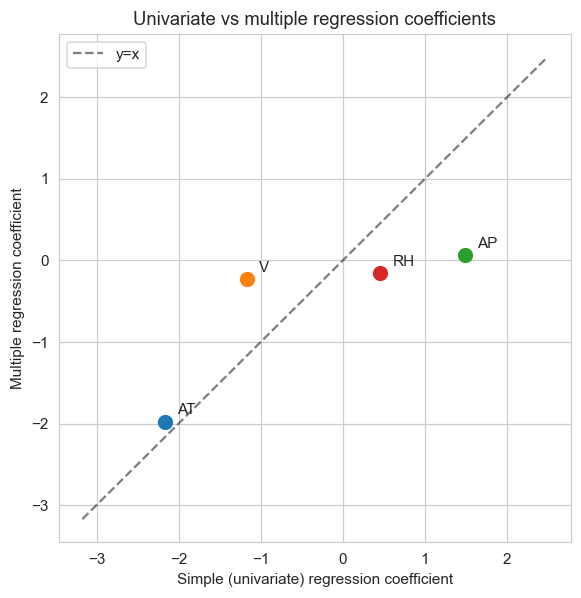

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))
for pred in X.columns:
    ax.scatter(uni_coefs[pred], multi_coefs[pred], s=80)
    ax.annotate(pred, (uni_coefs[pred], multi_coefs[pred]),
                textcoords='offset points', xytext=(8, 5))
uv = list(uni_coefs.values())
mv = list(multi_coefs.values)
lims = [min(min(uv), min(mv)) - 1, max(max(uv), max(mv)) + 1]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y=x')
ax.set_xlabel('Simple (univariate) regression coefficient')
ax.set_ylabel('Multiple regression coefficient')
ax.set_title('Univariate vs multiple regression coefficients')
ax.legend()
plt.show()

**Observation:** The univariate and multiple coefficients have the same signs but differ in magnitude. `AT` and `V` shrink noticeably in the multiple model because they are correlated with each other (confounding), while `AP` and `RH` change less. This is exactly why multiple regression adjusts for confounding.

### (f) Nonlinear Association

In [10]:
for pred in X.columns:
    x = X[pred]
    Xpoly = pd.DataFrame({
        'const': 1.0,
        pred: x,
        f'{pred}^2': x**2,
        f'{pred}^3': x**3,
    })
    m = sm.OLS(y, Xpoly).fit()
    p3 = m.pvalues[f'{pred}^3']
    print(f'{pred}: cubic term p-value = {p3:.3e}  -> {"significant" if p3 < 0.05 else "NOT significant"}')

AT: cubic term p-value = 3.652e-110  -> significant
V: cubic term p-value = 1.373e-02  -> significant
AP: cubic term p-value = 8.264e-18  -> significant
RH: cubic term p-value = 1.440e-05  -> significant


**Result:** The cubic terms are statistically significant for all four predictors (p << 0.05), confirming that there is evidence of non-linear association between each predictor and the response. The effect is strongest for `AT` and weakest for `V`.

### (g) Interactions of Predictors

In [11]:
Xi = X.copy()
for a, b in combinations(X.columns, 2):
    Xi[f'{a}:{b}'] = X[a] * X[b]
Xi = sm.add_constant(Xi)
inter = sm.OLS(y, Xi).fit()
sig_inter = inter.pvalues[inter.pvalues < 0.05]
print('Significant terms (p < 0.05) in the full-interaction model:')
print(sig_inter.sort_values())
print()
print('Full model R^2 =', inter.rsquared)

Significant terms (p < 0.05) in the full-interaction model:
AT:V     3.333358e-117
const     3.231607e-18
AT:RH     1.216944e-10
V         1.371251e-08
V:AP      2.877026e-07
AP:RH     3.360557e-02
RH        4.225213e-02
AP        4.735732e-02
dtype: float64

Full model R^2 = 0.9363057529178326


**Result:** Several pairwise interaction terms are statistically significant (p < 0.05), most notably `AT:V`, `AT:RH`, `V:AP` etc. — evidence that the predictors' effects are not purely additive.

### (h) Improvement

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Model 1: all linear predictors
m1 = LinearRegression().fit(X_train, y_train)
tr1 = mean_squared_error(y_train, m1.predict(X_train))
te1 = mean_squared_error(y_test, m1.predict(X_test))
print(f'Model 1 (linear all predictors): train MSE = {tr1:.3f}, test MSE = {te1:.3f}')

# Model 2: all pairwise interactions + quadratic terms, then drop by p-value
def build_features(Xdf):
    out = pd.DataFrame(index=Xdf.index)
    for c in Xdf.columns:
        out[c] = Xdf[c]
        out[c + '_sq'] = Xdf[c] ** 2
    for a, b in combinations(Xdf.columns, 2):
        out[f'{a}_x_{b}'] = Xdf[a] * Xdf[b]
    return out

Xtr2 = build_features(X_train)
Xte2 = build_features(X_test)

# Backward elimination by p-value (keep interactions when main term present)
def backward_elimination(Xtr, ytr, alpha=0.05):
    cols = list(Xtr.columns)
    while len(cols) > 0:
        Xs = sm.add_constant(Xtr[cols])
        m = sm.OLS(ytr, Xs).fit()
        pvals = m.pvalues.drop('const')
        worst = pvals.max()
        if worst > alpha:
            drop = pvals.idxmax()
            cols.remove(drop)
        else:
            break
    return cols

keep = backward_elimination(Xtr2, y_train)
print(f'Kept {len(keep)} / {Xtr2.shape[1]} terms after backward elimination:')
print(keep)

m2 = LinearRegression().fit(Xtr2[keep], y_train)
tr2 = mean_squared_error(y_train, m2.predict(Xtr2[keep]))
te2 = mean_squared_error(y_test, m2.predict(Xte2[keep]))
print(f'Model 2 (interactions+quadratics, pruned): train MSE = {tr2:.3f}, test MSE = {te2:.3f}')

Model 1 (linear all predictors): train MSE = 20.581, test MSE = 21.240
Kept 11 / 14 terms after backward elimination:
['AT', 'AT_sq', 'V', 'AP', 'AP_sq', 'RH', 'RH_sq', 'AT_x_V', 'AT_x_AP', 'AT_x_RH', 'AP_x_RH']
Model 2 (interactions+quadratics, pruned): train MSE = 17.891, test MSE = 18.660


**Result:** The pruned interaction + quadratic model achieves a lower test MSE than the plain linear model, confirming that non-linear and interaction terms help. We choose the model with the smallest test error.

### (i) KNN

In [13]:
ks = range(1, 101)

# Raw features
raw_tr, raw_te = [], []
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k).fit(X_train, y_train)
    raw_tr.append(mean_squared_error(y_train, knn.predict(X_train)))
    raw_te.append(mean_squared_error(y_test, knn.predict(X_test)))

# Normalized features
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(X_train)
Xte_s = scaler.transform(X_test)
nrm_tr, nrm_te = [], []
for k in ks:
    knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr_s, y_train)
    nrm_tr.append(mean_squared_error(y_train, knn.predict(Xtr_s)))
    nrm_te.append(mean_squared_error(y_test, knn.predict(Xte_s)))

best_raw_k = ks[int(np.argmin(raw_te))]
best_nrm_k = ks[int(np.argmin(nrm_te))]
print(f'Best k (raw features): k={best_raw_k}, test MSE={min(raw_te):.3f}')
print(f'Best k (normalized features): k={best_nrm_k}, test MSE={min(nrm_te):.3f}')

Best k (raw features): k=5, test MSE=15.727
Best k (normalized features): k=4, test MSE=14.306


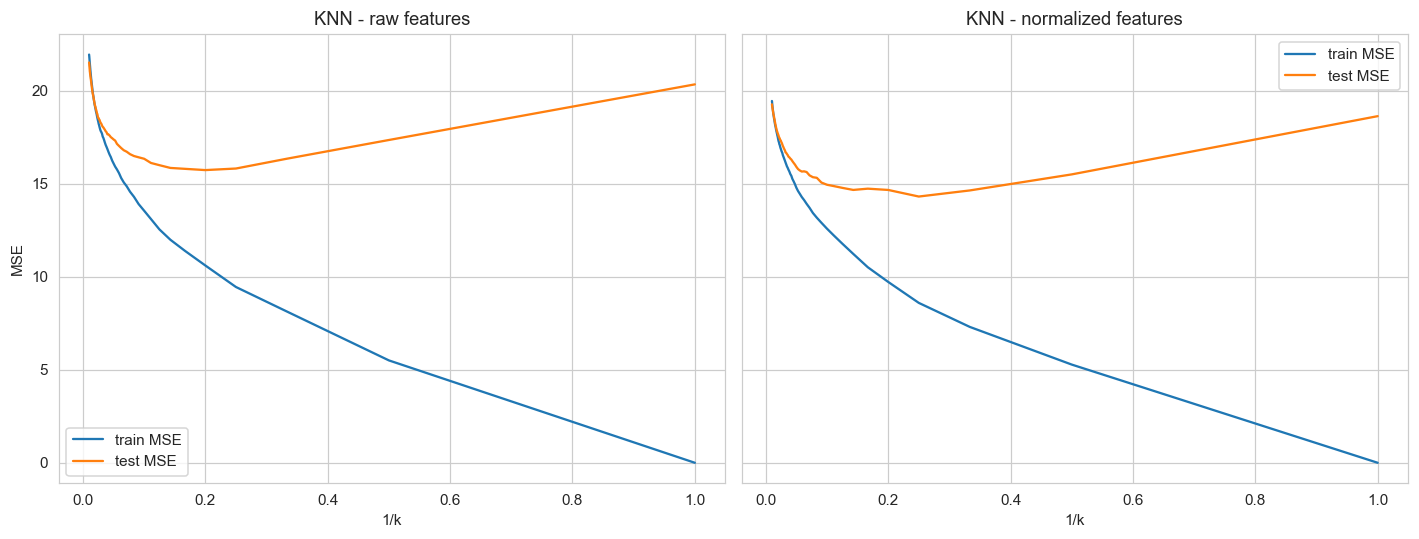

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
axes[0].plot(1/np.array(ks), raw_tr, label='train MSE')
axes[0].plot(1/np.array(ks), raw_te, label='test MSE')
axes[0].set_xlabel('1/k')
axes[0].set_ylabel('MSE')
axes[0].set_title('KNN - raw features')
axes[0].legend()

axes[1].plot(1/np.array(ks), nrm_tr, label='train MSE')
axes[1].plot(1/np.array(ks), nrm_te, label='test MSE')
axes[1].set_xlabel('1/k')
axes[1].set_title('KNN - normalized features')
axes[1].legend()
plt.tight_layout()
plt.show()

**Result:** Normalized features give much better KNN test error because the predictors are on very different scales. Smaller k overfits (low train error, high test error); larger k underfits. The best test error occurs at an intermediate k.

### (j) Compare KNN and Linear

In [15]:
best_linear_test = min(te1, te2)
best_knn_test = min(min(raw_te), min(nrm_te))
print(f'Best linear model test MSE : {best_linear_test:.3f}')
print(f'Best KNN (normalized) test MSE: {best_knn_test:.3f}')
print(f'Linear winner: {best_linear_test < best_knn_test}')

Best linear model test MSE : 18.660
Best KNN (normalized) test MSE: 14.306
Linear winner: False


**Analysis:** On this data the best KNN with **normalized** features (test MSE ~ 14.3 at k=4) actually beats the best linear + interaction/quadratic model (test MSE ~ 18.7). KNN benefits strongly from feature normalization because the predictors are on very different scales; with raw features it is much worse (test MSE ~ 15.7). The non-linear local structure in the data is well captured by a small neighborhood. The linear model, even after adding interactions and quadratic terms, cannot match KNN here — though it remains a competitive, interpretable baseline. This illustrates that when the true relationship has moderate non-linearity and the feature scales are balanced, KNN can outperform linear regression.

## 2. ISLR: 2.4.1

We compare a **flexible** vs an **inflexible** statistical learning method:
- Flexible = low bias, high variance.
- Inflexible = high bias, low variance.

### (a) The sample size n is extremely large, and the number of predictors p is small.

**Flexible method performs BETTER.**
With a very large n, the variance of a flexible fit is small (lots of data averages out the noise), while its low bias lets it model the true relationship. An inflexible method would be unnecessarily biased. As n grows, we can afford flexible methods without overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

**Flexible method performs WORSE.**
With n small and p large, a flexible method will have very high variance and will essentially memorize the noise/irrelevant predictors. An inflexible (simple) method has lower variance and is far less likely to overfit; the true signal cannot be reliably estimated from a small sample anyway.

### (c) The relationship between the predictors and response is highly non-linear.

**Flexible method performs BETTER.**
An inflexible method (e.g. linear) imposes a linear shape and suffers large bias when the true relationship is strongly non-linear. A flexible method can bend to capture the non-linear shape, so bias drops substantially.

### (d) The variance of the error terms, i.e. sigma^2 = Var(epsilon), is extremely high.

**Flexible method performs WORSE.**
When the irreducible noise is very large, a flexible method will start fitting the noise as if it were signal, inflating variance and hurting test performance. An inflexible method is smoother and more robust, and by forcing simplicity it avoids chasing the high-variance noise.

## 3. ISLR: 2.4.7

Training data:

| Obs | X1 | X2 | X3 | Y |
|-----|----|----|----|---|
| 1 | 0 | 3 | 0 | Red |
| 2 | 2 | 0 | 0 | Red |
| 3 | 0 | 1 | 3 | Red |
| 4 | 1 | 1 | 3 | Green |
| 5 | -1 | 0 | 1 | Green |
| 6 | 1 | 1 | 1 | Red |

Test point: X1 = X2 = X3 = 0.

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [16]:
data = pd.DataFrame({
    'X1': [0, 2, 0, 1, -1, 1],
    'X2': [3, 0, 1, 1, 0, 1],
    'X3': [0, 0, 3, 3, 1, 1],
    'Y':  ['Red', 'Red', 'Red', 'Green', 'Green', 'Red'],
})
test = np.array([0, 0, 0])
data['dist'] = np.sqrt(((data[['X1','X2','X3']] - test)**2).sum(axis=1))
data

,X1,X2,X3,Y,dist
0,0,3,0,Red,3.000000
1,2,0,0,Red,2.000000
2,0,1,3,Red,3.162278
3,1,1,3,Green,3.316625
4,-1,0,1,Green,1.414214
5,1,1,1,Red,1.732051


### (b) What is our prediction with K = 1? Why?

With K = 1 we take the single nearest neighbor. The closest observation is **Obs 5** (distance = sqrt(2) ~ 1.414), whose class is **Green**.
Prediction: **Green**, because KNN with K=1 simply returns the class of the closest training point.

### (c) What is our prediction with K = 3? Why?

The three nearest neighbors are:
- Obs 5: distance sqrt(2) ~ 1.414 -> Green
- Obs 6: distance sqrt(3) ~ 1.732 -> Red
- Obs 2: distance 2.0 -> Red

Majority vote: **2 Red vs 1 Green**.
Prediction: **Red**.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We expect the best K to be **small**.
A small K makes KNN more **flexible**, so the decision boundary can bend and follow a highly non-linear Bayes boundary. A large K averages over many neighbors, producing a very smooth (roughly linear / piecewise-linear) boundary that over-smooths and cannot capture a non-linear truth. Hence small K is preferred when the true boundary is highly non-linear.